In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
vp = 3e8
nt = 400
dx = 1e-3

S = 0.99                     # Courant number
dt = S * dx / vp
nt = 600

# ----------------------------
# Fields
# ----------------------------
E_curr = np.zeros(nt)
E_next = np.zeros(nt)
H = np.zeros(nt)

# ----------------------------
# Mur ABC storage
# ----------------------------
E_left_old = 0.0
E_right_old = 0.0

coef = (S - 1) / (S + 1)

# ----------------------------
# Source (Gaussian pulse)
# ----------------------------
t0 = 40
spread = 12
src = nt // 4

# snapshots para as fotos
snapshot_times = np.linspace(0, nt - 1, 4, dtype=int)
E_snapshots = []

# ----------------------------
# Time loop
# ----------------------------
for n in range(nt):

    # --- Update H (uses E_curr) ---
    for i in range(nt - 1):
        H[i] += (dt / dx) * (E_curr[i+1] - E_curr[i])

    # --- Update E_next (uses H) ---
    for i in range(1, nt):
        E_next[i] = E_curr[i] + (dt / dx) * (H[i] - H[i-1])

    # --- Source injection (soft) ---
    pulse = np.exp(-0.5 * ((n - t0) / spread)**2)
    E_next[src] += pulse

    # --- Mur ABC ---
    # Left boundary
    E_next[0] = E_curr[1] + coef * (E_next[1] - E_left_old)
    E_left_old = E_curr[0]

    # Right boundary
    E_next[-1] = E_curr[-2] + coef * (E_next[-2] - E_right_old)
    E_right_old = E_curr[-1]

    # --- Advance time step ---
    E_curr[:] = E_next[:]

    # tira as fotos
    if n in snapshot_times:
        E_snapshots.append(E_next.copy())

plt.ioff()
plt.show()

/tmp/ipykernel_103458/749710305.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right')


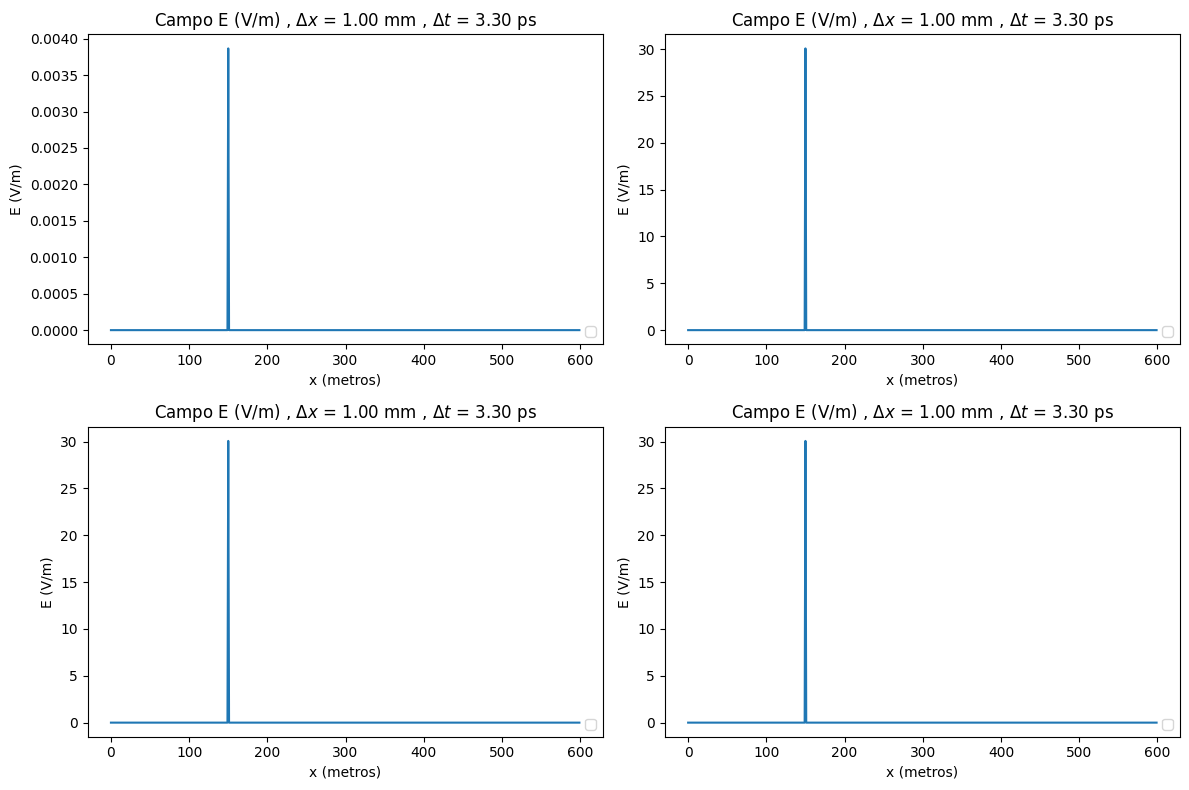

In [3]:
# plota as fotos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    ax.plot(E_snapshots[i])
    ax.set_title(fr"Campo E (V/m) , $\Delta x$ = {dx * 1e3:.2f} mm , $\Delta t$ = {dt * 1e12:.2f} ps")
    ax.set_xlabel("x (metros)")
    ax.set_ylabel(f"E (V/m)")
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()